<a href="https://colab.research.google.com/github/poojavelu/AI-tools-for-systems-engineering/blob/main/Weather_Forecasting_using_Transformer_Models/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stormer Tutorial: Medium-Range Weather Forecasting with Transformers

## Introduction: Weather Prediction as a Machine Learning Problem

Welcome! This tutorial introduces the fundamental ideas and practical application of the Stormer model, explaining how transformer architectures can be specialized for skillful and reliable medium-range weather forecasting.

Weather forecasting is traditionally tackled using Numerical Weather Prediction (NWP) models, which simulate atmospheric physics using complex differential equations. While powerful, NWP models are computationally expensive and don't inherently improve with more historical data.

Data-driven approaches, like Stormer, frame weather forecasting as a machine learning task. We learn patterns directly from vast amounts of historical weather data to predict future states. This approach is often much faster at inference time and can potentially capture complex dynamics missed by traditional parameterizations.

**Dataset: ERA5**

We'll be using data derived from the ERA5 reanalysis dataset provided by ECMWF. ERA5 combines historical observations with NWP models to create a globally complete and consistent dataset of atmospheric variables over decades. It typically includes variables like temperature, wind components, geopotential height, and humidity at various pressure levels (altitudes) and surface levels, arranged on a spatial grid (latitude/longitude) over time.

**Benchmark: WeatherBench2**

To evaluate Stormer, we use the WeatherBench2 benchmark. It provides standardized datasets (derived from ERA5 and others), evaluation metrics (like RMSE and ACC, which we'll discuss later), and baseline model results (like NWP models and other deep learning approaches like Pangu-Weather and GraphCast) for fair comparison.

**Stormer's Approach**

Stormer treats weather forecasting as a sequence-to-sequence problem on a spatio-temporal grid. It takes the current weather state (a grid of variables) as input and predicts the state at a future time step. We'll delve into its specific architecture and training techniques in the following sections.

# 1. Set-up: Installation of Required Packages

First, let's install the necessary Python libraries. We'll need `torch` for deep learning, `xarray`, `netcdf4`, and `cfgrib` for handling weather data formats, `matplotlib` for plotting, and `ipywidgets` for interactive elements.

In [ ]:
# Install required packages
!pip install torch torchvision xarray netcdf4 cfgrib matplotlib ipywidgets zarr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 137.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4

In [ ]:
# Enable ipywidgets extension for interactive elements in Jupyter
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json
Paths used for configuration of notebook: 
    	
      - Validating: OK
Paths used for configuration of notebook: 
    	/root/.jupyter/nbconfig/notebook.json


# 2. Dataset Preparation: Download and Preprocessing

## 2.1. Download Sample Dataset

We'll download a small sample from the WeatherBench2 ERA5 dataset stored in Google Cloud Storage. This sample contains the first 100 time steps (6-hourly intervals starting from 1959-01-01) for selected surface variables at a 1.4-degree resolution.

**Note:** Accessing the full dataset requires significant storage and might incur costs. This sample allows us to demonstrate the workflow.

The code below opens the remote Zarr dataset, selects specific variables (`2m_temperature`, `10m_u_component_of_wind`, `10m_v_component_of_wind`, `mean_sea_level_pressure`), takes the first 100 time steps, and saves it locally as a NetCDF file (`era5_sample.nc`) if it doesn't already exist.

In [ ]:
import netCDF4
import os
import xarray as xr
import zarr
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Define the remote dataset path and local file name
DATASET_NAME = "gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721_with_derived_variables.zarr"
LOCAL_DATASET_FILE = "era5_sample.nc"

# The full Stormer model uses many more variables (surface + 13 pressure levels)
# We pick a subset of these features for the purpose of this tutorial
SELECTED_FEATURES = [
    "2m_temperature",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "mean_sea_level_pressure",
]

In [ ]:
# Check if the local file exists, otherwise download and process
if not os.path.exists(LOCAL_DATASET_FILE):
  print(f"Local file {LOCAL_DATASET_FILE} not found. Downloading sample...")
  try:
    # Open the remote Zarr dataset anonymously
    ds_full = xr.open_zarr(DATASET_NAME, consolidated=True, storage_options={"token": "anon"})

    # Select the desired variables
    ds_vars = ds_full[SELECTED_FEATURES]

    # Select the first 100 time steps
    ds_time = ds_vars.isel(time=slice(0, 100))

    # Save the subset locally as a NetCDF file
    ds_time.to_netcdf(LOCAL_DATASET_FILE, engine="h5netcdf")
    print("Sample dataset downloaded and saved.")
  except Exception as e:
    print(f"Error downloading or processing data: {e}")
    print("Please ensure you have internet connectivity and necessary permissions.")
else:
  print(f"Using existing local file: {LOCAL_DATASET_FILE}")

Local file era5_sample.nc not found. Downloading sample...
Sample dataset downloaded and saved.


## 2.2. Data Pre-Processing

Now, we load the local dataset and perform basic preprocessing steps required for the model.

1.  **Load Data:** Open the NetCDF file using `xarray`.
2.  **Select Variables:** Ensure only the `SELECTED_FEATURES` are present (though they should be, based on the download step).
3.  **Normalization:** Deep learning models generally perform better with normalized data (mean 0, standard deviation 1). We compute the mean and standard deviation for each selected variable across the entire sample dataset (time, latitude, longitude dimensions). These statistics will be used to normalize the input data before feeding it to the model and to denormalize the model's output for evaluation.

**Note on Full Dataset Preprocessing:** For the full ERA5 dataset used in the paper, normalization statistics are typically computed only on the training split (e.g., 1979-2018) and then applied consistently to the validation and test splits.

In [ ]:
# Define normalization and denormalization functions
def normalize(x, mean, std):
    # Normalize a single variable tensor (T, H, W) or (H, W)
    # Add a small epsilon to std dev to prevent division by zero
    return (x - mean) / (std + 1e-8)

def denormalize(x, mean, std):
    # Denormalize a single variable tensor
    return x * (std + 1e-8) + mean

In [ ]:
TARGET_H = 64  # Target height (latitude points) after preprocessing
TARGET_W = 128 # Target width (longitude points) after preprocessing

try:
    # Open the local dataset
    ds = xr.open_dataset(LOCAL_DATASET_FILE)

    # Ensure only selected features are present (should be true from download step)
    ds = ds[SELECTED_FEATURES]

    # Display basic info about the loaded dataset
    print("Original Dataset Information:")
    print(ds)

    print(f"\nResampling data to H={TARGET_H}, W={TARGET_W}...")
    new_lat = np.linspace(-90, 90, TARGET_H)
    new_lon = np.linspace(0, 359, TARGET_W)
    ds = ds.interp(latitude=new_lat, longitude=new_lon, method="linear")
    print("Resampled Dataset Information:")
    print(ds)


    # Compute mean and standard deviation for normalization
    # For the actual model, these are computed on the training set only
    means = {var: float(ds[var].mean()) for var in SELECTED_FEATURES}
    stdevs = {var: float(ds[var].std()) for var in SELECTED_FEATURES}

    print("\nNormalization Means:", means)
    print("Normalization Std Devs:", stdevs)

    # Example: Normalize the '2m_temperature' variable
    t2m_data = ds['2m_temperature'].values # Get numpy array
    t2m_normalized = normalize(t2m_data, means['2m_temperature'], stdevs['2m_temperature'])

    print(f"\nShape of t2m data: {t2m_data.shape}")
    print(f"Mean of normalized t2m (should be approx 0): {t2m_normalized.mean():.4f}")
    print(f"Std dev of normalized t2m (should be approx 1): {t2m_normalized.std():.4f}")

    # Store dimensions for later use
    H, W = ds.dims['latitude'], ds.dims['longitude']
    V = len(SELECTED_FEATURES)

except FileNotFoundError:
    print(f"Error: {LOCAL_DATASET_FILE} not found. Please run the download cell first.")
except Exception as e:
    print(f"An error occurred during preprocessing: {e}")

Original Dataset Information:
<xarray.Dataset> Size: 2GB
Dimensions:                  (time: 100, latitude: 721, longitude: 1440)
Coordinates:
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.75 -90.0
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
  * time                     (time) datetime64[ns] 800B 1959-01-01 ... 1959-0...
Data variables:
    2m_temperature           (time, latitude, longitude) float32 415MB ...
    10m_u_component_of_wind  (time, latitude, longitude) float32 415MB ...
    10m_v_component_of_wind  (time, latitude, longitude) float32 415MB ...
    mean_sea_level_pressure  (time, latitude, longitude) float32 415MB ...

Resampling data to H=64, W=128...
Resampled Dataset Information:
<xarray.Dataset> Size: 26MB
Dimensions:                  (time: 100, latitude: 64, longitude: 128)
Coordinates:
  * time                     (time) datetime64[ns] 800B 1959-01-01 ... 1959-0...
  * latitude                 (latitude) flo

<ipython-input-23-f85711f19c23>:50: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  H, W = ds.dims['latitude'], ds.dims['longitude']


# 3. Architecture Exploration

With the dataset sample loaded, let's explore the core architectural components of Stormer. Stormer builds upon the Vision Transformer (ViT) but incorporates weather-specific modifications.

The Stormer architecture (from the paper) is shown below
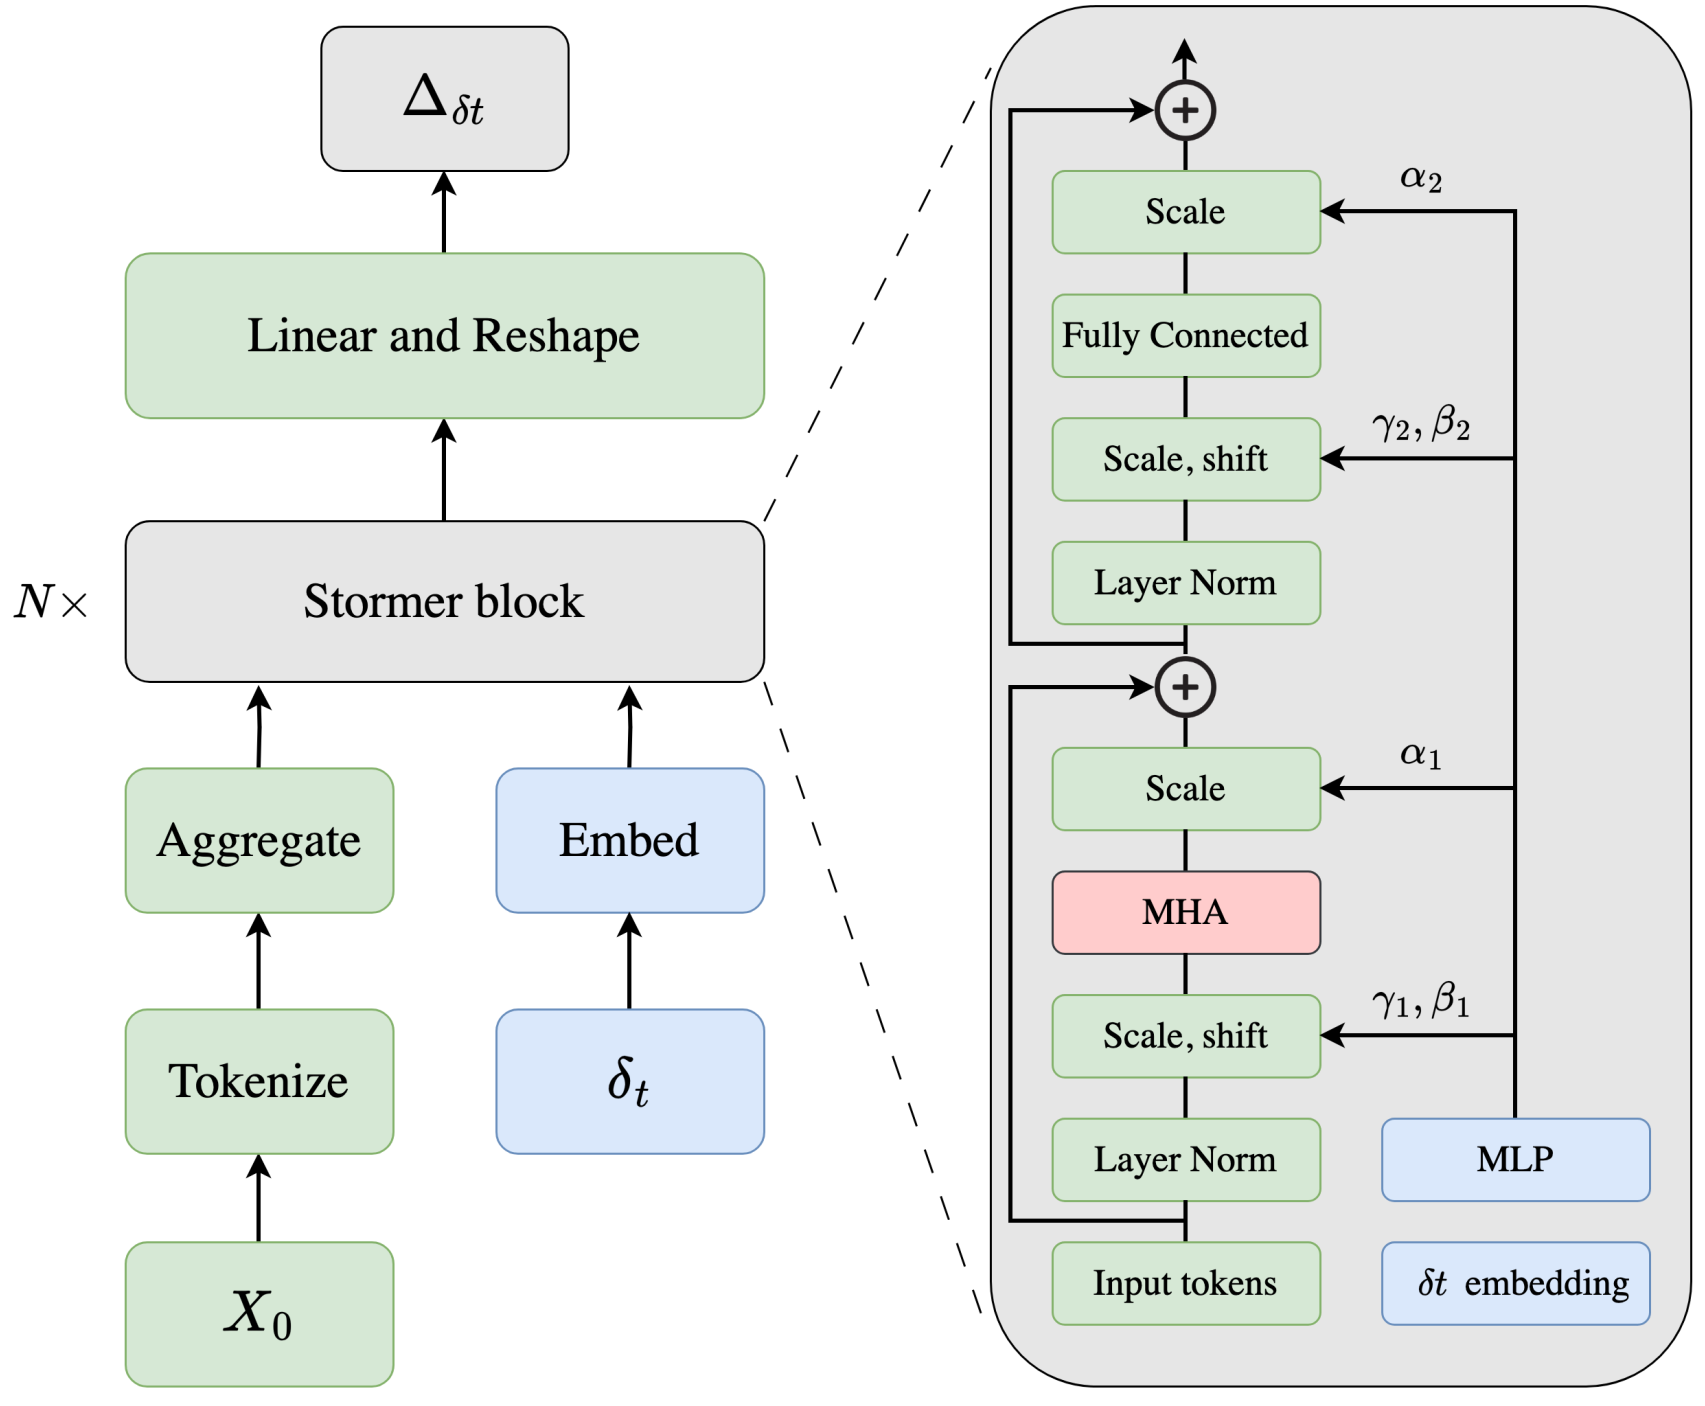


**Key Innovations:**

1.  **Weather-Specific Embedding:** Standard ViT flattens patches across all channels (variables). Stormer first tokenizes *each variable independently* and then uses a cross-attention mechanism to aggregate information across variables. This better captures the physical relationships between different atmospheric fields.
2.  **Variable Tokenization:** As part of the embedding, each variable's 2D field (H x W) is divided into non-overlapping patches (p x p), flattened, and linearly projected into the model's hidden dimension (D).
3.  **Adaptive Layer Normalization (AdaLN):** Standard Transformers add positional and other embeddings. Stormer incorporates the forecast time interval (δt) information *within* each Transformer block using AdaLN. Instead of fixed scale/shift parameters in LayerNorm, AdaLN computes these parameters dynamically based on an embedding of δt. This allows the model to adapt its processing based on the forecast interval.
4.  **Transformer Blocks:** The core processing uses standard Transformer blocks with multi-head self-attention (MHA) and feed-forward networks (MLP), conditioned using AdaLN.

## 3.1. Interactive Visualization of Input Data

Let's visualize the input fields for the selected variables at the first time step. Use the dropdown to select a variable.

In [ ]:
# Create dropdown widget for variable selection
variable_dropdown = widgets.Dropdown(
    options=SELECTED_FEATURES,
    value=SELECTED_FEATURES[0],
    description='Variable:',
    disabled=False,
)

# Create an output widget to display the plot
output_plot = widgets.Output()

# Function to update the plot based on dropdown selection
def plot_variable(change):
    with output_plot:
        clear_output(wait=True) # Clear previous plot
        selected_var = change['new']
        try:
            data_to_plot = ds[selected_var].isel(time=0)
            plt.figure(figsize=(10, 5))
            data_to_plot.plot(cmap='coolwarm')
            plt.title(f'Input Example: {selected_var} at Time 0')
            plt.xlabel('Longitude')
            plt.ylabel('Latitude')
            plt.show()
        except NameError:
            print("Dataset 'ds' not loaded. Please run the preprocessing cell.")
        except Exception as e:
            print(f"An error occurred during plotting: {e}")

# Link the dropdown's observe method to the plot function
variable_dropdown.observe(plot_variable, names='value')

# Display the dropdown and the initial plot
print("Select a variable to visualize its initial state:")
display(variable_dropdown)
display(output_plot)

# Trigger the plot function initially for the default value
plot_variable({'new': variable_dropdown.value})

Select a variable to visualize its initial state:


Dropdown(description='Variable:', options=('2m_temperature', '10m_u_component_of_wind', '10m_v_component_of_wi…

Output()

## 3.2. Conceptual Visualization: Patch Creation

The first step in the embedding process is dividing the input grid into patches. Here's a conceptual visualization using the T2m field.

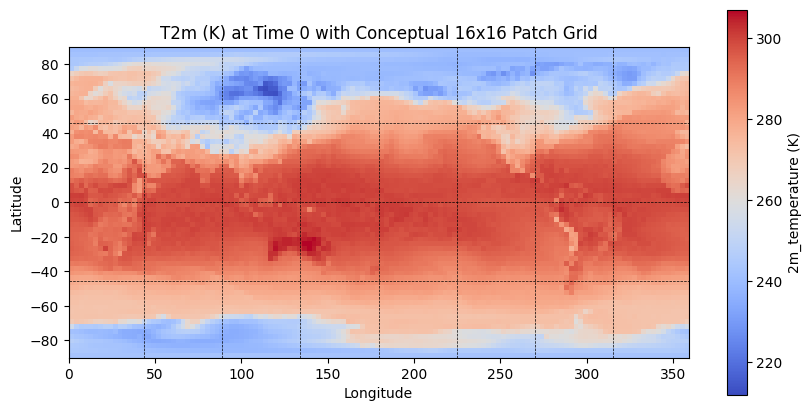

In [ ]:
def visualize_patches(data_array, patch_size, title):
    """Conceptually visualizes patch boundaries on a 2D data array."""
    plt.figure(figsize=(10, 5))
    plt.imshow(data_array, cmap='coolwarm', origin='lower',
               extent=[data_array.longitude.min(), data_array.longitude.max(),
                       data_array.latitude.min(), data_array.latitude.max()])
    plt.colorbar(label=f'{data_array.name} ({data_array.units})')

    h, w = data_array.shape
    lat_coords = data_array.latitude.values
    lon_coords = data_array.longitude.values

    # Draw horizontal patch lines
    for i in range(patch_size, h, patch_size):
        # Average latitude values for line placement
        lat_line = (lat_coords[i-1] + lat_coords[i]) / 2
        plt.axhline(lat_line, color='black', linestyle='--', linewidth=0.5)

    # Draw vertical patch lines
    for j in range(patch_size, w, patch_size):
        # Average longitude values for line placement
        lon_line = (lon_coords[j-1] + lon_coords[j]) / 2
        plt.axvline(lon_line, color='black', linestyle='--', linewidth=0.5)

    plt.title(f'{title} with Conceptual {patch_size}x{patch_size} Patch Grid')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.xlim(lon_coords.min(), lon_coords.max())
    plt.ylim(lat_coords.min(), lat_coords.max())
    plt.show()

try:
    # Visualize patches on the first time step of T2m
    visualize_patches(ds['2m_temperature'].isel(time=0), patch_size=16, title='T2m (K) at Time 0') # Use a larger patch size for visibility
except NameError:
    print("Dataset 'ds' not loaded.")
except Exception as e:
     print(f"An error occurred during patch visualization: {e}")

## 3.3. Code Walkthrough: Tokenization, Embedding, Transformer Blocks

Let's look at simplified Python classes representing the core ideas (referencing `stormer.py` and `weather_embedding.py` for the full implementation details used in the paper).

**Note:** The actual Stormer implementation uses more sophisticated details like specific activation functions (SiLU, GeLU), normalization layers (LayerNorm without elementwise affine), memory-efficient attention (from xformers), and careful weight initialization (truncated normal).

### 3.3.1. Variable Tokenization (Conceptual Part of WeatherEmbedding)

This step divides each variable's H x W field into non-overlapping patches (p x p), flattens each patch, and linearly projects it to the hidden dimension D. This is done *independently* for each variable.

In [ ]:
# Simplified representation of Patch Embedding (from timm library, used per variable)
# In Stormer's WeatherEmbedding, this is done within a loop or vectorized.
class SimplePatchEmbed(nn.Module):
    def __init__(self, patch_size=4, in_chans=1, embed_dim=64):
        super().__init__()
        self.patch_size = patch_size
        # Convolutional layer to create patches and project
        # Kernel size and stride = patch_size for non-overlapping patches
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: (B, 1, H, W) - representing one variable
        B, C, H_in, W_in = x.shape
        # Project and flatten: (B, embed_dim, H/p, W/p) -> (B, embed_dim, N_patches)
        x = self.proj(x).flatten(2)
        # Transpose to: (B, N_patches, embed_dim)
        x = x.transpose(1, 2)
        return x

# --- Example Usage ---
# Use dimensions defined in preprocessing cell
try:
    patch_size_arch = 4 # Example patch size for architecture
    hidden_dim_arch = 64
    B = 1 # Batch size

    input_tensor = torch.randn(B, V, H, W)
    patch_embedder = SimplePatchEmbed(patch_size=patch_size_arch, embed_dim=hidden_dim_arch)

    all_tokens = []
    for i in range(V):
        # Process each variable independently
        var_tokens = patch_embedder(input_tensor[:, i:i+1, :, :]) # Input needs shape (B, 1, H, W)
        all_tokens.append(var_tokens)

    # Stack tokens: List of V tensors of shape (B, N, D) -> (B, V, N, D)
    stacked_tokens = torch.stack(all_tokens, dim=1)
    N_patches_arch = (H // patch_size_arch) * (W // patch_size_arch)
    print(f"Shape after variable tokenization: {stacked_tokens.shape}") # Expected: (B, V, N_patches, D)
except NameError:
    print("Dimensions (V, H, W) not defined. Run preprocessing cell.")
except Exception as e:
     print(f"An error occurred: {e}")

Shape after variable tokenization: torch.Size([1, 4, 512, 64])


### 3.3.2. Weather-Specific Embedding (Aggregation & Positional Info)

This module (simplified here) takes the per-variable tokens, adds variable-specific embeddings and positional embeddings, and then aggregates across the variable dimension using cross-attention.

* **Variable Embeddings:** Learned vectors added to tokens to indicate which variable they belong to.
* **Positional Embeddings:** Learned or fixed (e.g., sinusoidal) vectors added to tokens to indicate their spatial position.
* **Variable Aggregation:** A cross-attention layer where a single learnable query attends to the tokens of all variables at the same spatial patch location, producing one aggregated token per patch location.

In [ ]:
# Simplified Weather Embedding - focusing on aggregation logic
class SimpleWeatherEmbed(nn.Module):
    def __init__(self, num_vars, num_patches, patch_size, hidden_dim, num_heads=8):
        super().__init__()
        self.num_vars = num_vars
        self.num_patches = num_patches
        self.hidden_dim = hidden_dim

        # --- Components represented conceptually ---
        # 1. Variable Tokenization (as shown above, happens before this module)

        # 2. Variable Embeddings (learned)
        self.var_embed = nn.Parameter(torch.zeros(1, num_vars, 1, hidden_dim))

        # 3. Positional Embeddings (learned)
        self.pos_embed = nn.Parameter(torch.zeros(1, 1, num_patches, hidden_dim))

        # 4. Variable Aggregation (Cross-Attention)
        self.agg_query = nn.Parameter(torch.zeros(1, 1, hidden_dim))
        self.agg_attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        # --- End Conceptual Components ---

    def forward(self, var_tokens):
        # var_tokens shape: (B, V, N, D)
        B, V_in, N_in, D_in = var_tokens.shape
        # Basic check - ideally more robust checks needed
        assert V_in == self.num_vars and N_in == self.num_patches and D_in == self.hidden_dim, "Input token shape mismatch"

        # Add variable and positional embeddings
        x = var_tokens + self.var_embed + self.pos_embed # Broadcasting applies

        # Reshape for aggregation: (B, V, N, D) -> (B*N, V, D)
        x = x.permute(0, 2, 1, 3).reshape(B * N_in, V_in, D_in)

        # Aggregate using cross-attention
        # Query shape: (B*N, 1, D), Key/Value shape: (B*N, V, D)
        query = self.agg_query.expand(B * N_in, -1, -1)
        agg_output, _ = self.agg_attn(query, x, x)
        # Output shape: (B*N, 1, D)

        # Reshape back: (B*N, 1, D) -> (B, N, D)
        final_tokens = agg_output.reshape(B, N_in, D_in)

        return final_tokens

# --- Example Usage ---
try:
    weather_embedder = SimpleWeatherEmbed(num_vars=V, num_patches=N_patches_arch,
                                          patch_size=patch_size_arch, hidden_dim=hidden_dim_arch)

    # Use the stacked_tokens from the previous step
    final_sequence = weather_embedder(stacked_tokens).to(device)
    print(f"Shape after Weather Embedding (inc. aggregation): {final_sequence.shape}") # Expected: (B, N, D)
except NameError:
     print("Variables (V, N_patches_arch, etc.) not defined. Run previous cells.")
except Exception as e:
     print(f"An error occurred: {e}")

Shape after Weather Embedding (inc. aggregation): torch.Size([1, 512, 64])


### 3.3.3. Stormer Transformer Block (with AdaLN)

This is a modification of a standard Transformer block. It includes Multi-Head Self-Attention (MHA) and a Feed-Forward Network (MLP). The key difference is the use of Adaptive Layer Normalization (AdaLN) which incorporates the time interval embedding (`t_emb`).

* **AdaLN:** Takes the time embedding `t_emb` and produces scale and shift parameters for the Layer Normalization layers, and also gating parameters (`gate_msa`, `gate_mlp`) that scale the outputs of the MHA and MLP sub-layers.

In [ ]:
# Simplified function to represent AdaLN modulation
def modulate(x, shift, scale):
    # x shape: (B, N, D)
    # shift, scale shape: (B, D)
    # Output shape: (B, N, D)
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

# Simplified Stormer Block with conceptual AdaLN
class SimpleStormerBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads=8, mlp_ratio=4.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        # LayerNorm without learnable affine parameters (handled by AdaLN)
        self.norm1 = nn.LayerNorm(hidden_dim, elementwise_affine=False)
        self.attn = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)

        self.norm2 = nn.LayerNorm(hidden_dim, elementwise_affine=False)
        mlp_hidden_dim = int(hidden_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden_dim),
            nn.GELU(), # GELU is common in Transformers
            nn.Linear(mlp_hidden_dim, hidden_dim),
        )

        # --- AdaLN Modulation (Conceptual) ---
        # In reality, this MLP takes t_emb and outputs 6*hidden_dim values
        # Often includes a SiLU activation before the final linear layer
        self.adaLN_mlp = nn.Sequential(
             nn.SiLU(), # Activation often used in AdaLN
             nn.Linear(hidden_dim, 6 * hidden_dim)
        )
        # --- End Conceptual ---

    def forward(self, x, t_emb):
        # x shape: (B, N, D), t_emb shape: (B, D)
        B, N, D = x.shape

        # --- Apply AdaLN ---
        # Generate scale/shift/gate parameters from time embedding
        ada_params = self.adaLN_mlp(t_emb) # Shape: (B, 6*D)
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = \
            torch.chunk(ada_params, 6, dim=1) # Each shape: (B, D)

        # 1. Self-Attention Path
        residual = x
        x_norm = self.norm1(x)
        x_modulated = modulate(x_norm, shift_msa, scale_msa)

        # CHUNKING: split Q into smaller chunks to reduce memory
        chunk_size = 8                                        # <<< CHUNKING: choose a chunk size
        attn_out_chunks = []                                  # <<< CHUNKING: buffer for pieces
        for i in range(0, N, chunk_size):
            q_chunk = x_modulated[:, i:i+chunk_size, :]       # (B, c, D)
            try:
              attn_chunk, _ = self.attn(
                  q_chunk,                                      # <<< CHUNKING
                  x_modulated,                                  # keys over full sequence
                  x_modulated                                   # values over full sequence
              )
            except RuntimeError as e:
                if "CUDA out of memory" in str(e):
                    print(f"OOM during attention calculation with q_chunk: {q_chunk.shape}, K/V: {x_modulated.shape}")
                    # Free some memory and retry
                    torch.cuda.empty_cache()
                    attn_chunk, _ = self.attn(q_chunk, x_modulated, x_modulated)
            attn_out_chunks.append(attn_chunk)                # <<< CHUNKING
        attn_output = torch.cat(attn_out_chunks, dim=1)       # (B, N, D)
        # END CHUNKING


        # MHA expects query, key, value. For self-attention, they are the same.
        # attn_output, _ = self.attn(x_modulated, x_modulated, x_modulated)
        # Apply gating and add residual
        x = residual + gate_msa.unsqueeze(1) * attn_output

        # 2. MLP Path
        residual = x
        x_norm = self.norm2(x)
        x_modulated = modulate(x_norm, shift_mlp, scale_mlp)
        mlp_output = self.mlp(x_modulated)
        # Apply gating and add residual
        x = residual + gate_mlp.unsqueeze(1) * mlp_output

        return x

# --- Example Usage ---
try:
    block = SimpleStormerBlock(hidden_dim=hidden_dim_arch, num_heads=8).to(device)

    # Need a dummy time embedding
    # In the real model, this comes from embedding the time interval (e.g., 6 hours)
    time_interval_emb = torch.randn(B, hidden_dim_arch).to(device)

    # Pass the sequence from the previous step through the block
    print("block")
    output_sequence = block(final_sequence.to(device), time_interval_emb)
    print(f"Shape after one Stormer Block: {output_sequence.shape}") # Expected: (B, N, D)
except NameError:
     print("Variables (hidden_dim_arch, final_sequence, etc.) not defined. Run previous cells.")
except Exception as e:
     print(f"An error occurred: {e}")

block
Shape after one Stormer Block: torch.Size([1, 512, 64])


### 3.3.4. Decoder (Conceptual)

After passing through N Stormer blocks, the final sequence of tokens (B, N, D) needs to be projected back to the original grid format (B, V, H, W). This is typically done with a linear layer that maps each token's D dimensions back to the flattened patch size for all variables (p * p * V), followed by reshaping.

# 4. Training

Stormer's training incorporates two key techniques:

1.  **Randomized Dynamics Forecasting:** Instead of training the model to predict at a single fixed interval (e.g., 6 hours), Stormer is trained to predict the *change* in weather state (`Δ_δt = X_δt - X_0`) over a *randomly sampled* time interval `δt` (e.g., chosen from {6, 12, 24} hours). The model takes `X_0` and `δt` as input and predicts `Δ_δt`. This encourages the model to learn dynamics across different timescales and acts as data augmentation.

2.  **Pressure-Weighted Loss:** Atmospheric variables exist at different pressure levels. Variables near the surface (higher pressure) are often more critical for many applications and represent denser parts of the atmosphere. This loss function assigns higher weights to errors in variables at higher pressure levels (closer to the surface) and lower weights to those at lower pressure levels (higher altitudes). It also incorporates latitude weighting to account for grid distortion near the poles.

3.  **Multi-Step Finetuning (Optional but recommended):** To improve performance for longer forecasts (which require multiple prediction steps, or 'rollouts'), the model can be finetuned using a loss computed over multiple steps (e.g., predict 4 steps ahead, average the loss). This helps mitigate error accumulation during inference.

## 4.1. Toy Dataset Version: Train a Mini-Stormer

We'll set up a simplified training loop using a toy dataset created from our small `era5_sample.nc`. This won't produce a realistic weather model but demonstrates the training process.

**Toy Data Generation:**
* We'll create pairs of (`X_0`, `X_δt`) from the loaded data.
* We'll randomly sample `δt` from a predefined set (e.g., {6, 12, 24} hours, corresponding to {1, 2, 4} time steps in our 6-hourly data).
* The target will be the normalized difference: `Δ_δt_norm = normalize_diff(X_δt - X_0, δt)`.
* The input will be the normalized `X_0_norm = normalize_input(X_0)` and the sampled `δt`.

**Mini-Stormer Model:**
* A smaller version of the architecture described above (fewer layers/smaller hidden dim).
* Includes simplified embedding, a few Stormer blocks, and a decoder head.

**Training Loop:**
* Standard PyTorch loop: forward pass, compute loss (MSE between predicted `Δ_δt_norm` and target `Δ_δt_norm`), backward pass, optimizer step.

**Ablation Toggles:**
* Use the checkboxes below to enable/disable randomized intervals and weighted loss before running the training cell.

In [ ]:
# --- Interactive Ablation Toggles ---
random_interval_toggle = widgets.Checkbox(
    value=True,
    description='Use Random Intervals (δt)?',
    disabled=False,
    indent=False
)
weighted_loss_toggle = widgets.Checkbox(
    value=False,
    description='Use Weighted Loss?',
    disabled=False,
    indent=False
)

print("Configure training settings:")
display(random_interval_toggle)
display(weighted_loss_toggle)

Configure training settings:


Checkbox(value=True, description='Use Random Intervals (δt)?', indent=False)

Checkbox(value=False, description='Use Weighted Loss?', indent=False)

In [ ]:
from torch.utils.data import DataLoader, Dataset
import random

# --- Hyperparameters & Toggles (Read from Widgets) ---
D_HIDDEN = 128        # Smaller hidden dimension for mini-model
N_BLOCKS = 4          # Fewer blocks
PATCH_SIZE = 8        # Larger patch size for faster toy training
NUM_HEADS = 4
INTERVAL_STEPS = {1, 2, 4} # Corresponds to {6, 12, 24} hours in 6-hourly data
LEARNING_RATE = 1e-4
EPOCHS = 3 # Very few epochs for demonstration
BATCH_SIZE = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Read values from widgets
USE_RANDOM_INTERVALS = random_interval_toggle.value
USE_WEIGHTED_LOSS = weighted_loss_toggle.value
print(f"Training with Random Intervals: {USE_RANDOM_INTERVALS}")
print(f"Training with Weighted Loss: {USE_WEIGHTED_LOSS}")

# --- Toy Dataset ---
class WeatherDataset(Dataset):
    def __init__(self, ds, variables, means, stds, interval_steps, use_random_intervals):
        self.ds = ds
        self.variables = variables
        self.means = means
        self.stds = stds
        self.interval_steps = list(interval_steps)
        self.use_random_intervals = use_random_intervals
        self.num_times = ds.dims['time']
        self.max_interval = max(interval_steps)

        # Precompute normalized data
        self.normalized_data = []
        for var in variables:
             self.normalized_data.append(normalize(ds[var].values, means[var], stds[var]))
        self.normalized_data = np.stack(self.normalized_data, axis=1) # Shape: (T, V, H, W)

    def __len__(self):
        # Ensure we don't go out of bounds when selecting X_dt
        return self.num_times - self.max_interval

    def __getitem__(self, idx):
        if self.use_random_intervals:
            dt_step = random.choice(self.interval_steps)
        else:
            dt_step = self.interval_steps[0] # Use the smallest fixed interval

        idx_dt = idx + dt_step

        x0_norm = torch.tensor(self.normalized_data[idx], dtype=torch.float32)
        xdt_norm = torch.tensor(self.normalized_data[idx_dt], dtype=torch.float32)

        # Target is the normalized difference
        delta_norm = xdt_norm - x0_norm

        # Represent interval dt (in hours for the model, e.g., 6, 12, 24)
        # The model expects this scaled, e.g., by /10.0
        dt_hours = float(dt_step * 6)
        dt_tensor = torch.tensor([dt_hours / 10.0], dtype=torch.float32)

        return x0_norm, delta_norm, dt_tensor

# --- Simplified Mini-Stormer Model ---
# Using the conceptual blocks from Section 3 for simplicity
class MiniStormer(nn.Module):
    def __init__(self, num_vars, num_patches, patch_size, hidden_dim, n_blocks, num_heads):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.num_vars = num_vars
        self.H = H // patch_size # Use global H, W defined in preprocessing
        self.W = W // patch_size

        # 1. Embedding (Simplified - combines tokenization, aggregation, pos/var embeds)
        # Use V channels directly in Conv2d for simplified projection
        self.input_proj = nn.Conv2d(num_vars, hidden_dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, hidden_dim))
        self.time_embedder = nn.Linear(1, hidden_dim) # Embed dt

        # 2. Transformer Blocks (Simplified AdaLN)
        self.blocks = nn.ModuleList([
            SimpleStormerBlock(hidden_dim, num_heads) for _ in range(n_blocks)
        ])

        # 3. Decoder Head
        self.norm_final = nn.LayerNorm(hidden_dim)
        self.head = nn.Linear(hidden_dim, patch_size * patch_size * num_vars)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.pos_embed, std=0.02)
        self.apply(self._init_linear_layer_weights)

    def _init_linear_layer_weights(self, m):
         if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
         elif isinstance(m, nn.LayerNorm):
            if m.elementwise_affine: # Only if affine=True
                 nn.init.constant_(m.bias, 0)
                 nn.init.constant_(m.weight, 1.0)

    def unpatchify(self, x):
        # x: (B, N, P*P*V)
        B, N, _ = x.shape
        p = self.patch_size
        v = self.num_vars
        h, w = self.H, self.W
        # Reshape assuming P*P*V is the last dimension
        x = x.reshape(B, h, w, p, p, v)
        x = torch.einsum('nhwpqv->nvhpwq', x)
        imgs = x.reshape(B, v, h * p, w * p)
        return imgs

    def forward(self, x, dt):
        # x: (B, V, H, W)
        # dt: (B, 1)
        B, V_in, H_in, W_in = x.shape

        # Simplified Embedding
        # Project and flatten: (B, V, H, W) -> (B, D, H/p, W/p) -> (B, D, N) -> (B, N, D)
        x = self.input_proj(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed

        t_emb = self.time_embedder(dt) # (B, D)
        x = x + t_emb.unsqueeze(1) # Add time embedding to all tokens

        # Transformer Blocks
        for blk in self.blocks:
            x = blk(x, t_emb) # Pass time embedding for AdaLN

        # Decoder
        x = self.norm_final(x)
        x = self.head(x) # (B, N, P*P*V)
        output_delta = self.unpatchify(x) # (B, V, H, W)

        return output_delta

# --- Instantiate Dataset, DataLoader, Model, Optimizer, Loss ---
try:
    # Ensure H, W, V are defined from preprocessing cell
    if 'H' not in globals() or 'W' not in globals() or 'V' not in globals():
        raise NameError("Dimensions H, W, or V not defined. Run preprocessing cell.")

    N_PATCHES = (H // PATCH_SIZE) * (W // PATCH_SIZE)

    weather_dataset = WeatherDataset(ds, SELECTED_FEATURES, means, stdevs, INTERVAL_STEPS, USE_RANDOM_INTERVALS)
    dataloader = DataLoader(weather_dataset, batch_size=BATCH_SIZE, shuffle=True)

    mini_model = MiniStormer(V, N_PATCHES, PATCH_SIZE, D_HIDDEN, N_BLOCKS, NUM_HEADS).to(DEVICE)
    optimizer = torch.optim.Adam(mini_model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()

    train_losses = [] # Store average loss per epoch

    print(f"Mini-model initialized with {sum(p.numel() for p in mini_model.parameters()):,} parameters.")

    # --- Simplified Training Loop ---
    print("Starting toy training...")
    mini_model.train()
    for ep in range(EPOCHS):
        epoch_loss = 0
        for i, (x0_batch, delta_norm_batch, dt_batch) in enumerate(dataloader):
            x0_batch, delta_norm_batch, dt_batch = \
                x0_batch.to(DEVICE), delta_norm_batch.to(DEVICE), dt_batch.to(DEVICE)

            optimizer.zero_grad()
            pred_delta_norm = mini_model(x0_batch, dt_batch)

            if USE_WEIGHTED_LOSS:
                # Simplified weighting: equal weight per variable, latitude weighting
                lat_coords = torch.tensor(ds['latitude'].values).to(DEVICE)
                lat_weights = torch.cos(torch.deg2rad(lat_coords))
                lat_weights = lat_weights / lat_weights.mean() # Normalize
                # Expand weights to match batch and variable dimensions: (B, V, H, W)
                weights = lat_weights.unsqueeze(0).unsqueeze(0).unsqueeze(-1).expand_as(delta_norm_batch)
                loss = torch.mean(weights * (pred_delta_norm - delta_norm_batch)**2)
            else:
                loss = criterion(pred_delta_norm, delta_norm_batch)

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

            # Print batch loss less frequently
            if i % 10 == 0:
                print(f"  Epoch {ep+1}, Batch {i}/{len(dataloader)}, Loss: {loss.item():.6f}")

        avg_loss = epoch_loss / len(dataloader)
        train_losses.append(avg_loss)
        print(f"Epoch {ep+1}/{EPOCHS} finished. Average Loss: {avg_loss:.6f}")
    print("Toy training finished.")

except NameError as e:
     print(f"Error during training setup: {e}. Ensure dataset 'ds' and dimensions are loaded.")
except Exception as e:
     print(f"An error occurred during training: {e}")

Using device: cuda
Training with Random Intervals: True
Training with Weighted Loss: False


<ipython-input-14-3a740a188878>:31: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  self.num_times = ds.dims['time']


Mini-model initialized with 1,270,144 parameters.
Starting toy training...
  Epoch 1, Batch 0/48, Loss: 1.206888
  Epoch 1, Batch 10/48, Loss: 0.805972
  Epoch 1, Batch 20/48, Loss: 0.651726
  Epoch 1, Batch 30/48, Loss: 0.557337
  Epoch 1, Batch 40/48, Loss: 0.396401
Epoch 1/3 finished. Average Loss: 0.668036
  Epoch 2, Batch 0/48, Loss: 0.536673
  Epoch 2, Batch 10/48, Loss: 0.499761
  Epoch 2, Batch 20/48, Loss: 0.326710
  Epoch 2, Batch 30/48, Loss: 0.513374
  Epoch 2, Batch 40/48, Loss: 0.370466
Epoch 2/3 finished. Average Loss: 0.396364
  Epoch 3, Batch 0/48, Loss: 0.405029
  Epoch 3, Batch 10/48, Loss: 0.324630
  Epoch 3, Batch 20/48, Loss: 0.243242
  Epoch 3, Batch 30/48, Loss: 0.217414
  Epoch 3, Batch 40/48, Loss: 0.324556
Epoch 3/3 finished. Average Loss: 0.298003
Toy training finished.


## 4.2. Conceptual Training Loss Visualization

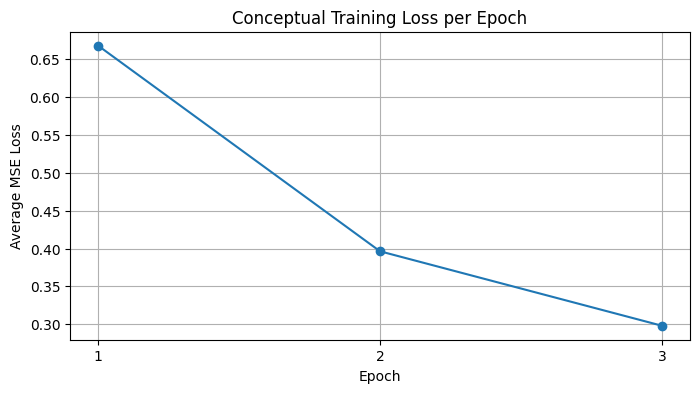

In [ ]:
# Plot the conceptual training loss
try:
    if train_losses:
        plt.figure(figsize=(8, 4))
        plt.plot(range(1, EPOCHS + 1), train_losses, marker='o')
        plt.title('Conceptual Training Loss per Epoch')
        plt.xlabel('Epoch')
        plt.ylabel('Average MSE Loss')
        plt.xticks(range(1, EPOCHS + 1))
        plt.grid(True)
        plt.show()
    else:
        print("Training loss data not available. Run the training cell first.")
except NameError:
    print("Training loss data ('train_losses') not found. Run the training cell first.")
except Exception as e:
     print(f"An error occurred plotting loss: {e}")

## 4.3. Pressure-Weighted MSE Loss (Conceptual Code)

Here's how the pressure-weighted loss (combined with latitude weighting) might be implemented conceptually. It requires knowing the pressure level for each variable.

**Note:** This requires a mapping from variable names to pressure levels and uses the `lat_weighted_mse` utility function (from `iterative_module.py`'s imports, not fully defined here).

In [ ]:
# Conceptual implementation of pressure-weighted MSE
# Assumes 'lat_weighted_mse' function is available and handles weighting

# Example pressure levels (replace with actual values for the full variable set)
pressure_levels = {
    '2m_temperature': 1013, # Approximate surface pressure in hPa
    '10m_u_component_of_wind': 1013,
    '10m_v_component_of_wind': 1013,
    'mean_sea_level_pressure': 1013
    # ... add pressure levels for all other variables used in full model
}

# Create a weight dictionary based on pressure levels
WEIGHT_DICT_CONCEPT = {var: pressure_levels.get(var, 1000) for var in SELECTED_FEATURES}
print("Conceptual Weight Dictionary (higher value = higher weight):")
print(WEIGHT_DICT_CONCEPT)

Conceptual Weight Dictionary (higher value = higher weight):
{'2m_temperature': 1013, '10m_u_component_of_wind': 1013, '10m_v_component_of_wind': 1013, 'mean_sea_level_pressure': 1013}


# 5. Inference and Evaluation

Once trained, Stormer predicts future weather states iteratively.

**Inference Strategies:**

Because Stormer is trained with randomized intervals (δt), it can generate a forecast for a target lead time `T` using different *sequences* of prediction steps.

1.  **Homogeneous Rollouts:** Use only one interval type repeatedly. Example for T=24 hours (assuming δt ∈ {6, 12, 24}):
    * Rollout 6-hour predictions 4 times: `X_0 -> X_6 -> X_12 -> X_18 -> X_24`
    * Rollout 12-hour predictions 2 times: `X_0 -> X_12 -> X_24`
    * Rollout 24-hour prediction 1 time: `X_0 -> X_24`
2.  **Heterogeneous Rollouts:** Mix different intervals. Example for T=24 hours:
    * `X_0 -> X_6 -> X_18 -> X_24` (using δt=6, δt=12, δt=6)
    * Many other combinations exist.

**Ensembling:**
Stormer generates multiple forecasts for the same target time `T` using different rollout strategies (e.g., all homogeneous ones, or a selection of heterogeneous ones like 'best m in n' from the paper). The final forecast is the *average* (ensemble mean) of these individual forecasts. This averaging significantly improves accuracy, especially for longer lead times where individual forecast trajectories might diverge due to chaos.

**Evaluation Metrics:**

* **RMSE (Root Mean Squared Error):** Measures the average magnitude of the errors between forecast and ground truth for each variable. Lower is better. Often latitude-weighted.
* **ACC (Anomaly Correlation Coefficient):** Measures the correlation between the *anomalies* (deviations from the long-term average/climatology) of the forecast and the ground truth. It assesses the model's ability to predict deviations from the average weather pattern. Higher (closer to 1) is better. Often latitude-weighted.

**Baselines:**
Performance is compared against:
* **Climatology:** Predicting the long-term average weather for that time of year.
* **Persistence:** Predicting the current weather will persist.
* **NWP Models:** Like the operational IFS model.
* **Other DL Models:** Like GraphCast and Pangu-Weather.

## 5.1. Interactive Widgets for Inference

Use the widgets below to select the variable and target forecast lead time (in hours) for the visualization in the next section.

In [ ]:
# Widget to select inference strategy (conceptual)
strategy_widget_inf = widgets.ToggleButtons(
    options=['homogeneous', 'best_m_in_n'],
    description='Strategy:',
    value='homogeneous', # Default strategy
    disabled=False,
    button_style='',
    tooltips=['Use only single interval rollouts', 'Use best M from N combinations (conceptual)']
)

# Widget to select variable for forecast visualization
variable_dropdown_inf = widgets.Dropdown(
    options=SELECTED_FEATURES,
    value=SELECTED_FEATURES[0],
    description='Variable:',
    disabled=False,
)

# Widget to select target forecast hour
# Create options based on available data (up to 96 hours = 16 steps of 6h for 100 steps total)
max_forecast_step = (len(ds.time) - max(INTERVAL_STEPS)) -1 # Max index for X0
max_forecast_hour = max_forecast_step * 6
forecast_hour_options = [h for h in range(6, max_forecast_hour + 1, 6)] # Forecast every 6 hours

hour_dropdown_inf = widgets.Dropdown(
    options=forecast_hour_options,
    value=24, # Default to 24 hours
    description='Forecast Hour:',
    disabled=False,
)

print("Configure forecast visualization settings:")
display(strategy_widget_inf)
display(variable_dropdown_inf)
display(hour_dropdown_inf)

Configure forecast visualization settings:


ToggleButtons(description='Strategy:', options=('homogeneous', 'best_m_in_n'), tooltips=('Use only single inte…

Dropdown(description='Variable:', options=('2m_temperature', '10m_u_component_of_wind', '10m_v_component_of_wi…

Dropdown(description='Forecast Hour:', index=3, options=(6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84…

## 5.2. Forecast Heatmaps and Quantitative Metrics

Let's visualize the conceptual forecast based on the widget selections above and plot example metrics.

**Note:** We'll use the *untrained* `mini_model` here just to demonstrate the plotting. A real forecast requires the fully trained model and proper data handling.

In [ ]:
# --- Conceptual Forecasting & Plotting ---

# Function to perform a conceptual forecast rollout (using untrained model)
def conceptual_forecast(model, x0_norm, target_hours, strategy, device): # Removed unused 'variables'
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        # --- Homogeneous Strategy ---
        # For demo, we'll average the 3 homogeneous rollouts if possible
        all_preds_norm = []
        print(f"conceptual_forecast: target_hours={target_hours}, x0_norm_shape={x0_norm.shape}")

        for interval in [6, 12, 24]: # Hours
            if target_hours % interval == 0:
                steps = target_hours // interval
                print(f"  Trying interval={interval}h, steps={steps}")

                current_x_batch_size = x0_norm.shape[0]
                interval_value = interval / 10.0
                # Ensure interval_tensor has shape (batch_size, 1)
                interval_tensor = torch.full((current_x_batch_size, 1), interval_value, dtype=torch.float32).to(device)

                current_x_norm = x0_norm.clone().to(device)
                for step_num in range(steps):
                    print(f"    Rollout step {step_num + 1}/{steps} for interval {interval}h")
                    print(f"      Input current_x_norm shape: {current_x_norm.shape}")
                    print(f"      Input interval_tensor shape: {interval_tensor.shape}") # Should be [B, 1]
                    pred_delta_norm = model(current_x_norm, interval_tensor)
                    print(f"      Output pred_delta_norm shape: {pred_delta_norm.shape}")
                    current_x_norm = current_x_norm + pred_delta_norm
                    print(f"      Updated current_x_norm shape: {current_x_norm.shape}")
                all_preds_norm.append(current_x_norm)

        if not all_preds_norm:
            print(f"  Warning: No rollouts made for intervals [6,12,24] for target_hours={target_hours}.")
            # Fallback: just use 6h steps if possible
            if target_hours % 6 == 0:
                print(f"  Fallback: Trying 6h steps for target_hours={target_hours}.")
                steps = target_hours // 6
                interval = 6

                current_x_batch_size = x0_norm.shape[0]
                interval_value = interval / 10.0
                # Ensure interval_tensor has shape (batch_size, 1)
                interval_tensor = torch.full((current_x_batch_size, 1), interval_value, dtype=torch.float32).to(device)

                current_x_norm = x0_norm.clone().to(device)
                for step_num in range(steps):
                    print(f"    Fallback rollout step {step_num + 1}/{steps} for interval {interval}h")
                    print(f"      Input current_x_norm shape: {current_x_norm.shape}")
                    print(f"      Input interval_tensor shape: {interval_tensor.shape}") # Should be [B, 1]
                    pred_delta_norm = model(current_x_norm, interval_tensor)
                    print(f"      Output pred_delta_norm shape: {pred_delta_norm.shape}")
                    current_x_norm = current_x_norm + pred_delta_norm
                    print(f"      Updated current_x_norm shape: {current_x_norm.shape}")
                all_preds_norm.append(current_x_norm)
            else:
                print(f"  Error: Cannot make {target_hours}h forecast with any strategy. Returning input x0_norm.")
                return x0_norm.cpu() # Return input if no valid rollout

        if not all_preds_norm:
            print("  Error: all_preds_norm is still empty after all attempts. This should not happen. Returning input x0_norm.")
            return x0_norm.cpu()

        print(f"  Number of predictions in all_preds_norm: {len(all_preds_norm)}")
        for i, pred_tensor in enumerate(all_preds_norm):
            print(f"    Shape of pred_tensor {i}: {pred_tensor.shape}")

        try:
            stacked_preds = torch.stack(all_preds_norm)
            print(f"  Shape of stacked_preds: {stacked_preds.shape}")

            if stacked_preds.ndim == 0:
                final_pred_norm = stacked_preds
                print("  stacked_preds is a scalar.")
            elif stacked_preds.ndim == 1:
                final_pred_norm = stacked_preds.mean()
                print("  stacked_preds is 1D, taking simple mean.")
            else:
                final_pred_norm = stacked_preds.mean(dim=0)
                print(f"  Calculated mean along dim=0. final_pred_norm shape: {final_pred_norm.shape}")

        except RuntimeError as e_stack:
            print(f"  RuntimeError during torch.stack or .mean(): {e_stack}")
            print("  This might happen if tensors in all_preds_norm have inconsistent shapes or all_preds_norm is empty.")
            return x0_norm.cpu()

        if strategy == 'best_m_in_n':
            print("  Conceptual 'best m in n': Using averaged homogeneous for demo.")
            pass

    return final_pred_norm.cpu()

In [ ]:
# --- Visualization Code ---
def plot_forecast_comparison(target_var, target_hr, pred_denorm, gt_denorm, lat_coords, lon_coords):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    cmap = 'coolwarm'

    valid_pred = pred_denorm[~np.isnan(pred_denorm)]
    valid_gt = gt_denorm[~np.isnan(gt_denorm)]

    if valid_pred.size == 0 and valid_gt.size == 0: vmin, vmax = 0,1
    else:
        all_valid = np.concatenate([valid_pred, valid_gt]) if valid_pred.size > 0 and valid_gt.size > 0 else (valid_pred if valid_pred.size > 0 else valid_gt)
        if all_valid.size > 0: vmin, vmax = np.nanmin(all_valid), np.nanmax(all_valid)
        else: vmin, vmax = 0,1

    common_args = {'cmap': cmap, 'vmin': vmin, 'vmax': vmax, 'origin': 'lower',
                   'extent': [lon_coords.min(), lon_coords.max(), lat_coords.min(), lat_coords.max()]}

    axes[0].imshow(gt_denorm, **common_args)
    axes[0].set_title(f'Ground Truth {target_var} at T={target_hr}h')
    axes[1].imshow(pred_denorm, **common_args)
    axes[1].set_title(f'Forecast {target_var} at T={target_hr}h (Toy Model)')

    error = pred_denorm - gt_denorm
    valid_err = error[~np.isnan(error)]
    err_max_abs = np.abs(valid_err).max() if valid_err.size > 0 else 1

    im_err = axes[2].imshow(error, cmap='coolwarm', vmin=-err_max_abs, vmax=err_max_abs, origin='lower', extent=common_args['extent'])
    axes[2].set_title(f'Error (Forecast - Truth) at T={target_hr}h')

    for ax_idx, ax in enumerate(axes):
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        try:
            if ax_idx < 2: fig.colorbar(ax.images[0], ax=ax, shrink=0.7, label=f'{target_var} Value')
            else: fig.colorbar(im_err, ax=ax, shrink=0.7, label='Error')
        except IndexError: pass
    plt.tight_layout()
    plt.show()

Generating conceptual forecast for 2m_temperature at 24 hours using 'homogeneous' strategy...
Initial x0_vis_norm shape: torch.Size([1, 4, 64, 128]), on device: cuda:0
conceptual_forecast: target_hours=24, x0_norm_shape=torch.Size([1, 4, 64, 128])
  Trying interval=6h, steps=4
    Rollout step 1/4 for interval 6h
      Input current_x_norm shape: torch.Size([1, 4, 64, 128])
      Input interval_tensor shape: torch.Size([1, 1])
      Output pred_delta_norm shape: torch.Size([1, 4, 64, 128])
      Updated current_x_norm shape: torch.Size([1, 4, 64, 128])
    Rollout step 2/4 for interval 6h
      Input current_x_norm shape: torch.Size([1, 4, 64, 128])
      Input interval_tensor shape: torch.Size([1, 1])
      Output pred_delta_norm shape: torch.Size([1, 4, 64, 128])
      Updated current_x_norm shape: torch.Size([1, 4, 64, 128])
    Rollout step 3/4 for interval 6h
      Input current_x_norm shape: torch.Size([1, 4, 64, 128])
      Input interval_tensor shape: torch.Size([1, 1])
      O

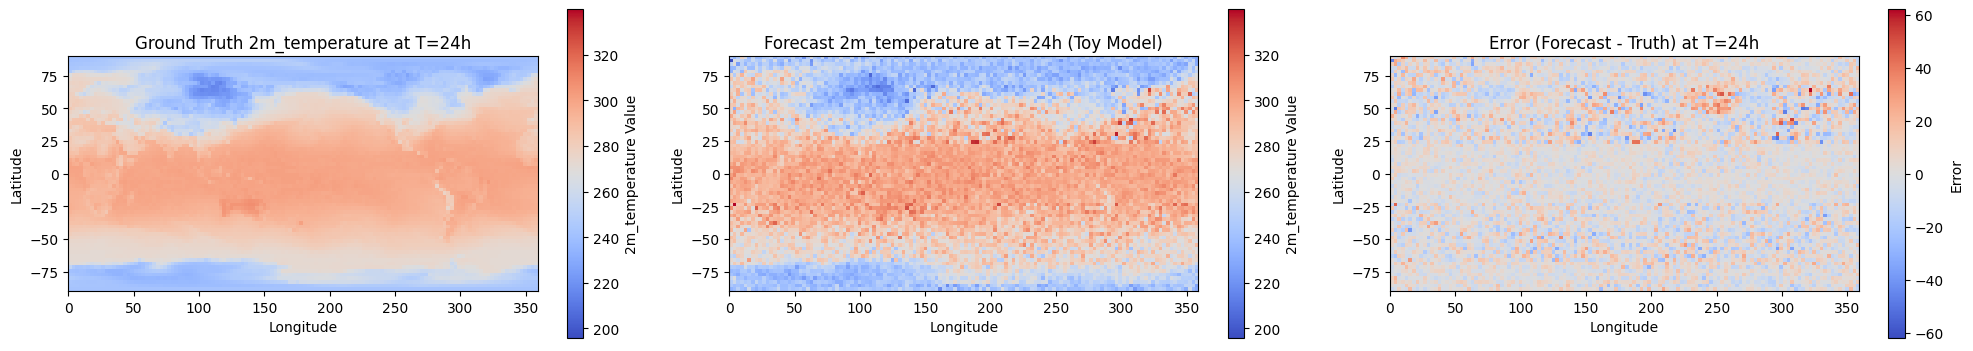

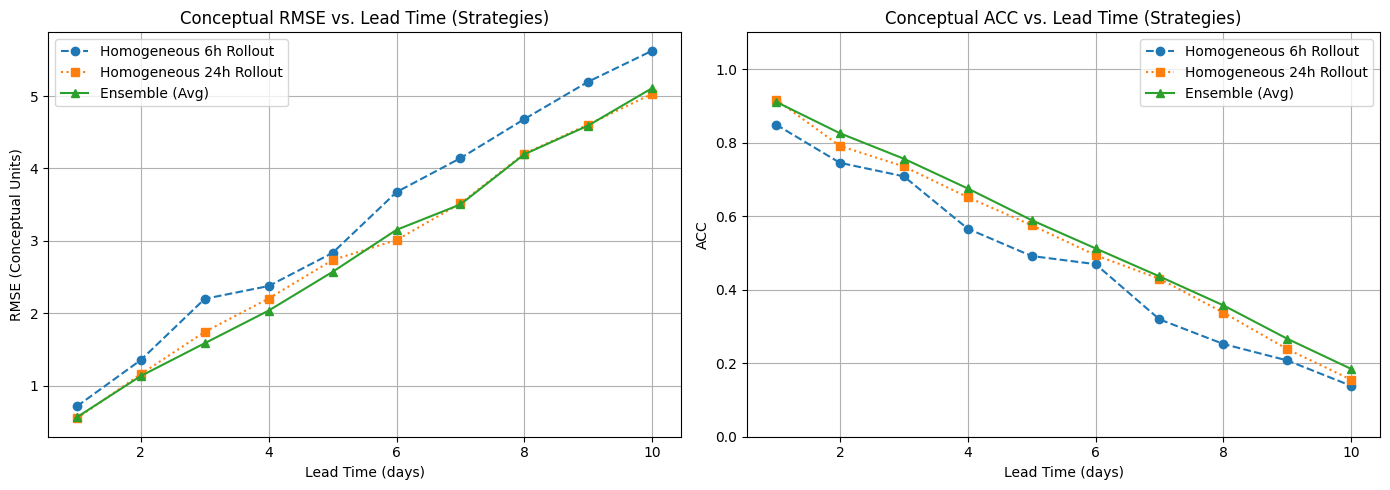

In [ ]:
# --- Run Forecast and Plot ---
try:
    # Ensure all necessary variables from previous cells are loaded
    if 'strategy_widget_inf' not in globals() or \
       'variable_dropdown_inf' not in globals() or \
       'hour_dropdown_inf' not in globals():
        # Fallback if widgets are not defined (e.g. running as pure script)
        print("Warning: Interactive widgets not found. Using default inference parameters.")
        class DummyWidget:
            def __init__(self, value): self.value = value
        strategy_widget_inf = DummyWidget('homogeneous')
        variable_dropdown_inf = DummyWidget(SELECTED_FEATURES[0] if SELECTED_FEATURES else '2m_temperature')
        hour_dropdown_inf = DummyWidget(24)

    if 'weather_dataset' not in globals() or weather_dataset is None:
        raise NameError("weather_dataset not defined. Run section 4.1.")
    if 'mini_model' not in globals() or mini_model is None:
        raise NameError("mini_model not defined. Run section 4.1.")
    if 'ds' not in globals() or ds is None:
        raise NameError("xarray dataset 'ds' not defined. Run section 2.2.")
    if 'means' not in globals() or not means or 'stdevs' not in globals() or not stdevs: # Check if means/stdevs are populated
        raise NameError("Normalization 'means' or 'stdevs' not defined or empty. Run section 2.2.")
    # Ensure denormalize is available (it should be if section 2.2 ran from the full script)
    if 'denormalize' not in globals():
        raise NameError("Function 'denormalize' is not defined. Ensure section 2.2 has run.")


    selected_strategy_inf = strategy_widget_inf.value
    selected_var_inf = variable_dropdown_inf.value
    selected_hour_inf = hour_dropdown_inf.value

    x0_from_dataset, _, _ = weather_dataset[0]
    x0_vis_norm = x0_from_dataset.clone().detach().unsqueeze(0).to(DEVICE)

    print(f"Generating conceptual forecast for {selected_var_inf} at {selected_hour_inf} hours using '{selected_strategy_inf}' strategy...")
    print(f"Initial x0_vis_norm shape: {x0_vis_norm.shape}, on device: {x0_vis_norm.device}")

    pred_norm = conceptual_forecast(mini_model, x0_vis_norm, selected_hour_inf,
                                    selected_strategy_inf, DEVICE)

    print(f"Shape of pred_norm returned by conceptual_forecast: {pred_norm.shape}")

    var_index = SELECTED_FEATURES.index(selected_var_inf)
    if pred_norm.ndim == 4 and pred_norm.shape[0] == 1:
        pred_var_norm_tensor = pred_norm[0, var_index]
    elif pred_norm.ndim == 3:
        pred_var_norm_tensor = pred_norm[var_index]
    else:
        raise ValueError(f"Unexpected shape for pred_norm: {pred_norm.shape}")

    pred_var_denorm = denormalize(pred_var_norm_tensor.cpu().numpy(), means[selected_var_inf], stdevs[selected_var_inf])

    target_step_index = selected_hour_inf // 6
    if target_step_index < ds.sizes['time']:
        gt_var_data_xr = ds[selected_var_inf].isel(time=target_step_index).data
        if hasattr(gt_var_data_xr, 'compute'): gt_var_denorm = gt_var_data_xr.compute()
        else: gt_var_denorm = np.asarray(gt_var_data_xr)

        plot_forecast_comparison(selected_var_inf, selected_hour_inf, pred_var_denorm, gt_var_denorm, ds.latitude.values, ds.longitude.values)
    else:
        print(f"Error: Target hour {selected_hour_inf}h is beyond the available data range ({ds.sizes['time']*6}h max).")

    lead_times_days = np.arange(1, 11)
    base_rmse = 0.5 * lead_times_days
    base_acc = 1.0 - 0.08 * lead_times_days
    rmse_6h = base_rmse + np.random.rand(10) * 0.5 + 0.2
    acc_6h = base_acc - np.random.rand(10) * 0.1 - 0.05
    rmse_24h = base_rmse + np.random.rand(10) * 0.3
    acc_24h = base_acc - np.random.rand(10) * 0.05
    rmse_ensemble = base_rmse + np.random.rand(10) * 0.2
    acc_ensemble = base_acc - np.random.rand(10) * 0.02
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(lead_times_days, rmse_6h, marker='o', linestyle='--', label='Homogeneous 6h Rollout')
    axes[0].plot(lead_times_days, rmse_24h, marker='s', linestyle=':', label='Homogeneous 24h Rollout')
    axes[0].plot(lead_times_days, rmse_ensemble, marker='^', linestyle='-', label='Ensemble (Avg)')
    axes[0].set_title('Conceptual RMSE vs. Lead Time (Strategies)')
    axes[0].set_xlabel('Lead Time (days)'); axes[0].set_ylabel('RMSE (Conceptual Units)'); axes[0].grid(True); axes[0].legend()
    axes[1].plot(lead_times_days, acc_6h, marker='o', linestyle='--', label='Homogeneous 6h Rollout')
    axes[1].plot(lead_times_days, acc_24h, marker='s', linestyle=':', label='Homogeneous 24h Rollout')
    axes[1].plot(lead_times_days, acc_ensemble, marker='^', linestyle='-', label='Ensemble (Avg)')
    axes[1].set_title('Conceptual ACC vs. Lead Time (Strategies)')
    axes[1].set_xlabel('Lead Time (days)'); axes[1].set_ylabel('ACC'); axes[1].set_ylim(0, 1.1); axes[1].grid(True); axes[1].legend()
    plt.tight_layout()
    plt.show()

except NameError as e:
     print(f"Error during inference/plotting: {e}. Ensure model and data (weather_dataset, mini_model, ds, means, stdevs, denormalize) are loaded from previous cells.")
except Exception as e:
     print(f"An error occurred during inference/plotting: {e}")
     raise

# 6. Scalability

A key aspect of the Stormer paper is demonstrating the model's scalability. The results show that:

* **Model Size:** Increasing model capacity (number of layers, hidden dimension size - similar to ViT-Small, Base, Large variants) consistently improves forecast accuracy, especially at longer lead times.
* **Patch Size:** Decreasing the patch size (e.g., from p=8 to p=2) significantly improves performance. Smaller patches mean the input is divided into more tokens, increasing the sequence length processed by the Transformer. This allows the model to capture finer-grained spatial details but also increases computational cost.
* **Training Tokens:** Performance generally improves as the model sees more data (more epochs or larger datasets).

These findings suggest that Stormer, like standard Transformers in other domains, benefits from scaling up compute, model size, and data, indicating potential for further improvements beyond the results presented in the paper.

## Conclusion

This tutorial provided an overview of the Stormer model, highlighting how a Transformer architecture, adapted with weather-specific embeddings, adaptive normalization, randomized dynamics training, and weighted loss, can achieve state-of-the-art performance in medium-range weather forecasting. We explored the data, architecture, training, inference, and evaluation aspects, demonstrating the key concepts through simplified code examples.